In [106]:
print("CodeAlpha - Credit Scoring Model")
print("Machine Learning Internship")

CodeAlpha - Credit Scoring Model
Machine Learning Internship


In [107]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [108]:
data = {
    'Income': [25000, 45000, 30000, 60000, 22000, 75000, 50000, 28000, 90000, 35000,
               40000, 65000, 27000, 80000, 32000, 55000, 24000, 70000, 48000, 38000],

    'Debt': [15000, 10000, 18000, 5000, 16000, 4000, 8000, 14000, 3000, 12000,
             9000, 6000, 17000, 4000, 13000, 7000, 15000, 5000, 9000, 11000],

    'Payment_History': [60, 90, 65, 95, 55, 98, 85, 62, 99, 75,
                        82, 94, 58, 97, 68, 88, 57, 96, 84, 72],

    'Creditworthy': [0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
                     1, 1, 0, 1, 0, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(data)

df.head()

,Income,Debt,Payment_History,Creditworthy
0,25000,15000,60,0
1,45000,10000,90,1
2,30000,18000,65,0
3,60000,5000,95,1
4,22000,16000,55,0


In [109]:
X = df[['Income', 'Debt', 'Payment_History']]
y = df['Creditworthy']

print("Features (X):")
print(X)

print("\nTarget (y):")
print(y)

Features (X):
    Income   Debt  Payment_History
0    25000  15000               60
1    45000  10000               90
2    30000  18000               65
3    60000   5000               95
4    22000  16000               55
5    75000   4000               98
6    50000   8000               85
7    28000  14000               62
8    90000   3000               99
9    35000  12000               75
10   40000   9000               82
11   65000   6000               94
12   27000  17000               58
13   80000   4000               97
14   32000  13000               68
15   55000   7000               88
16   24000  15000               57
17   70000   5000               96
18   48000   9000               84
19   38000  11000               72

Target (y):
0     0
1     1
2     0
3     1
4     0
5     1
6     1
7     0
8     1
9     1
10    1
11    1
12    0
13    1
14    0
15    1
16    0
17    1
18    1
19    0
Name: Creditworthy, dtype: int64


In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16, 3)
Testing data: (4, 3)


In [111]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [112]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [113]:
y_pred = model.predict(X_test_scaled)

print("Predicted values:")
print(y_pred)

Predicted values:
[0 1 1 1]


In [114]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])

print("Model Evaluation Results")
print("------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", roc_auc)

Model Evaluation Results
------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0
ROC-AUC  : 1.0


Confusion Matrix:
[[1 0]
 [0 3]]


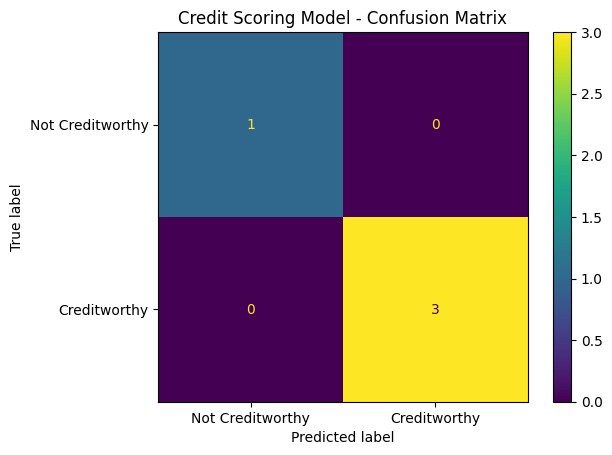

In [115]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Creditworthy", "Creditworthy"]
)

disp.plot()
plt.title("Credit Scoring Model - Confusion Matrix")
plt.show()

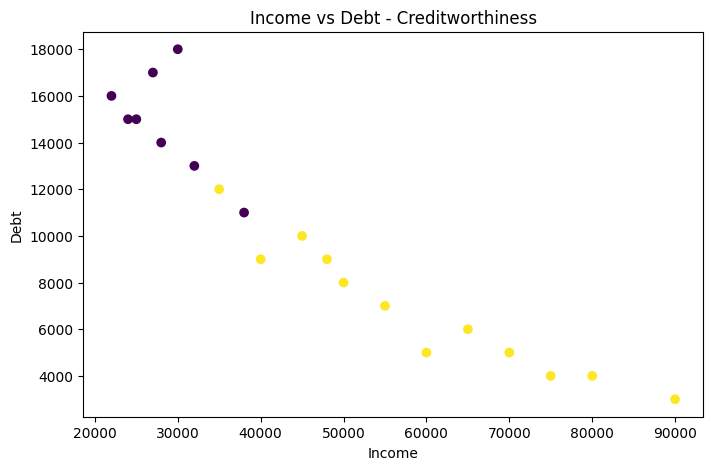

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Income"],
    df["Debt"],
    c=df["Creditworthy"]
)

plt.xlabel("Income")
plt.ylabel("Debt")
plt.title("Income vs Debt - Creditworthiness")
plt.show()

In [117]:
import joblib

joblib.dump(model, "credit_scoring_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [118]:
new_customer = pd.DataFrame({
    'Income': [50000],
    'Debt': [8000],
    'Payment_History': [90]
})

new_customer_scaled = scaler.transform(new_customer)

prediction = model.predict(new_customer_scaled)

if prediction[0] == 1:
    print("Prediction: Creditworthy")
else:
    print("Prediction: Not Creditworthy")

Prediction: Creditworthy


In [119]:
probability = model.predict_proba(new_customer_scaled)

print("Probability of Not Creditworthy:", probability[0][0])
print("Probability of Creditworthy:", probability[0][1])

Probability of Not Creditworthy: 0.10501230436861919
Probability of Creditworthy: 0.8949876956313808


In [120]:
print("===== CREDIT SCORING MODEL RESULTS =====")
print(f"Accuracy  : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")
print(f"F1-Score  : {f1:.2f}")
print(f"ROC-AUC   : {roc_auc:.2f}")

===== CREDIT SCORING MODEL RESULTS =====
Accuracy  : 1.00
Precision : 1.00
Recall    : 1.00
F1-Score  : 1.00
ROC-AUC   : 1.00
